<a href="https://colab.research.google.com/github/tbkashin/Machine-Learning/blob/Homework/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1


k = 2: Silhouette Score = 0.6404
k = 3: Silhouette Score = 0.6898
k = 4: Silhouette Score = 0.7945
k = 5: Silhouette Score = 0.7291
k = 6: Silhouette Score = 0.7440


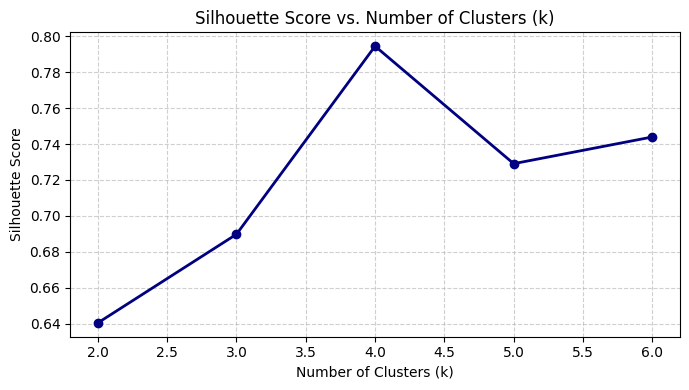

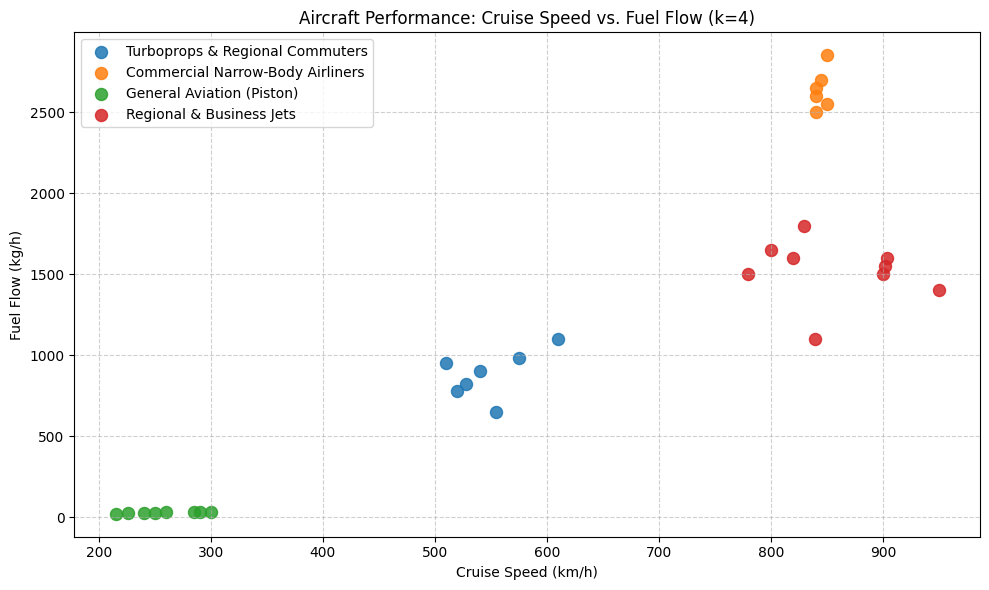

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv('aircraft_performance.csv')
features = ['Speed_kmh', 'FuelFlow_kgph']
X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Silhouette score computation for k in range 2 to 6
k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}: Silhouette Score = {score:.4f}")

# Plot Silhouette Score vs. k
plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='navy', linewidth=2)
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Fit kmeans with optimal k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Scatter plot
cluster_labels = {
    0: 'Turboprops & Regional Commuters',
    1: 'Commercial Narrow-Body Airliners',
    2: 'General Aviation (Piston)',
    3: 'Regional & Business Jets'
}

plt.figure(figsize=(10, 6))
for c_id in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c_id]
    plt.scatter(sub['Speed_kmh'], sub['FuelFlow_kgph'], label=cluster_labels[c_id], s=75, alpha=0.85)


plt.title('Aircraft Performance: Cruise Speed vs. Fuel Flow (k=4)')
plt.xlabel('Cruise Speed (km/h)')
plt.ylabel('Fuel Flow (kg/h)')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Question 2


/tmp/ipykernel_810/2238282923.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_price_norm = float(x_test @ theta_final)


Batch Size =  1 | theta_0 = -3.9158, theta_1 = 1.2853 | Final J = 4.8084 | Predicted Price = $166,485.19
Batch Size =  5 | theta_0 = -2.9755, theta_1 = 1.1571 | Final J = 4.6830 | Predicted Price = $155,377.00
Batch Size = 10 | theta_0 = -1.9722, theta_1 = 1.0190 | Final J = 4.8282 | Predicted Price = $143,315.23
Batch Size = 20 | theta_0 = -1.1272, theta_1 = 0.9267 | Final J = 5.1799 | Predicted Price = $137,008.20


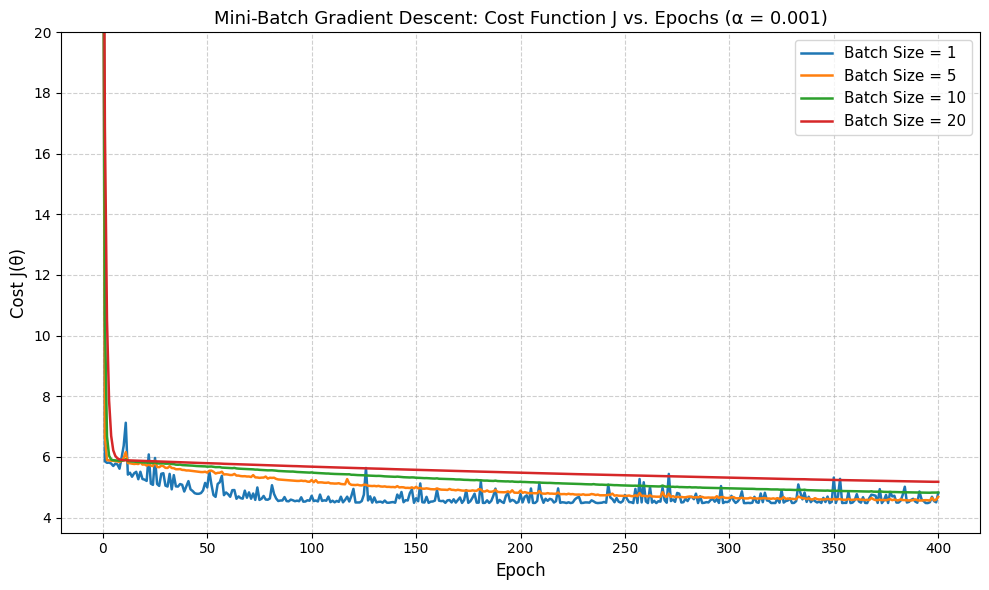

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
datafile = 'housing_prices.txt'
data = np.loadtxt(datafile, delimiter=',')
x_raw = data[:, 0]  # Population in 10,000s
y_raw = data[:, 1]  # Price in $10,000s
m = len(y_raw)

# Intercept x_0 = 1
X = np.c_[np.ones(m), x_raw]
y = y_raw.reshape(-1, 1)

# Define Cost Function theta
def compute_cost(X, y, theta):
    m = len(y)
    diff = X @ theta - y
    return (1.0 / (2.0 * m)) * np.sum(diff ** 2)

# Mini-Batch Gradient Descent Function
def mini_batch_gradient_descent(X, y, batch_size, alpha=0.001, epochs=400, random_seed=42):
    np.random.seed(random_seed)
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = [compute_cost(X, y, theta)]

    for epoch in range(epochs):
        # Shuffle indices each epoch
        indices = np.random.permutation(m)
        X_shuff = X[indices]
        y_shuff = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuff[i:i + batch_size]
            y_batch = y_shuff[i:i + batch_size]
            b_size = len(y_batch)

            grad = (1.0 / b_size) * (X_batch.T @ (X_batch @ theta - y_batch))
            theta = theta - alpha * grad

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# Train across batch sizes: 1, 5, 10, 20
batch_sizes = [1, 5, 10, 20]
alpha = 0.001
epochs = 400
pop_target = 160000 / 10000.0  # x = 16.0 (since population is given in 10,000s)

plt.figure(figsize=(10, 6))

for b in batch_sizes:
    theta_final, cost_hist = mini_batch_gradient_descent(X, y, batch_size=b, alpha=alpha, epochs=epochs)

    # Predict for city with population of 160,000
    x_test = np.array([1.0, pop_target])
    pred_price_norm = float(x_test @ theta_final)
    pred_price_dollars = pred_price_norm * 10000.0

    print(f"Batch Size = {b:2d} | "
          f"theta_0 = {theta_final[0,0]:.4f}, theta_1 = {theta_final[1,0]:.4f} | "
          f"Final J = {cost_hist[-1]:.4f} | "
          f"Predicted Price = ${pred_price_dollars:,.2f}")

    plt.plot(range(len(cost_hist)), cost_hist, label=f'Batch Size = {b}', linewidth=1.8)

# Plot creation
plt.title('Mini-Batch Gradient Descent: Cost Function J vs. Epochs (α = 0.001)', fontsize=13)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cost J(θ)', fontsize=12)
plt.ylim(3.5, 20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Question 3


Top 2 Selected Features: ['worst area' 'worst concave points']
Accuracy:  0.9415
Precision: 0.9450
Recall:    0.9626
F1-Score:  0.9537
ROC-AUC:   0.9777

Classification Report:
               precision    recall  f1-score   support

   malignant       0.94      0.91      0.92        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



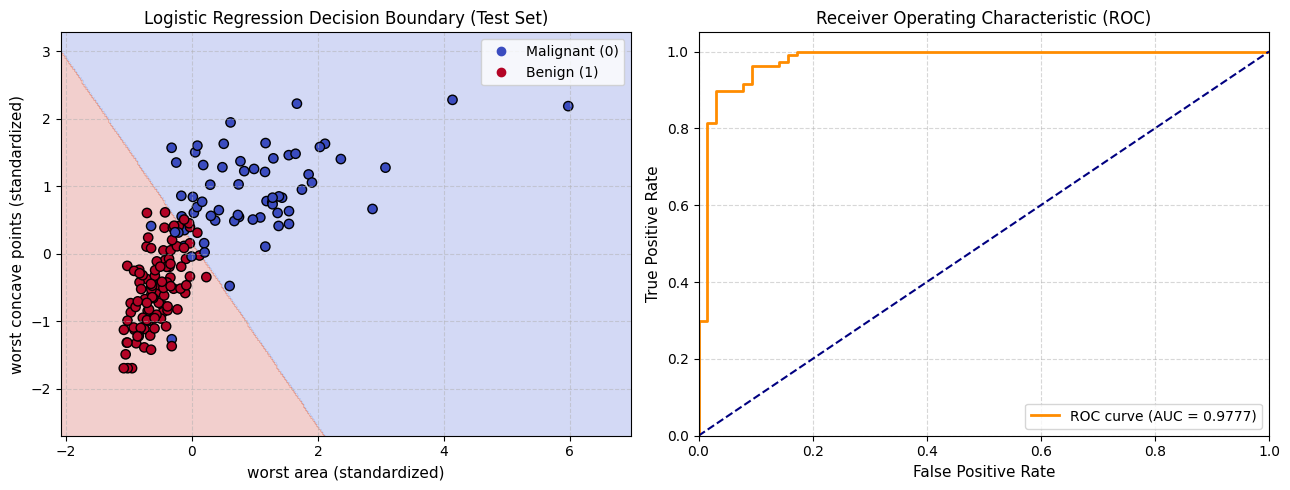

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

# 70%-30% Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Recursive Feature Elimination to select best 2 features
base_lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
rfe = RFE(estimator=base_lr, n_features_to_select=2)
rfe.fit(X_train_scaled, y_train)

selected_mask = rfe.support_
best_features = feature_names[selected_mask]
print("Top 2 Selected Features:", best_features)

# Train Logistic Regression on selected 2 features
X_train_sub = X_train_scaled[:, selected_mask]
X_test_sub = X_test_scaled[:, selected_mask]

model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X_train_sub, y_train)

# Model Evaluation
y_pred = model.predict(X_test_sub)
y_pred_proba = model.predict_proba(X_test_sub)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# Visualization: Decision Boundary & ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Decision Boundary
x_min, x_max = X_test_sub[:, 0].min() - 1, X_test_sub[:, 0].max() + 1
y_min, y_max = X_test_sub[:, 1].min() - 1, X_test_sub[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax1.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
scatter = ax1.scatter(X_test_sub[:, 0], X_test_sub[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', s=45)
ax1.set_title('Logistic Regression Decision Boundary (Test Set)', fontsize=12)
ax1.set_xlabel(f'{best_features[0]} (standardized)', fontsize=11)
ax1.set_ylabel(f'{best_features[1]} (standardized)', fontsize=11)
ax1.legend(scatter.legend_elements()[0], ['Malignant (0)', 'Benign (1)'], loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('Receiver Operating Characteristic (ROC)', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Question 4


Validation MSE: 11.8572
Validation R2 Score: 0.5691
Validation MAE: 2.1195

Predicted House Price (in $10,000s): 13.9702
Predicted House Price (in USD): $139,702.45


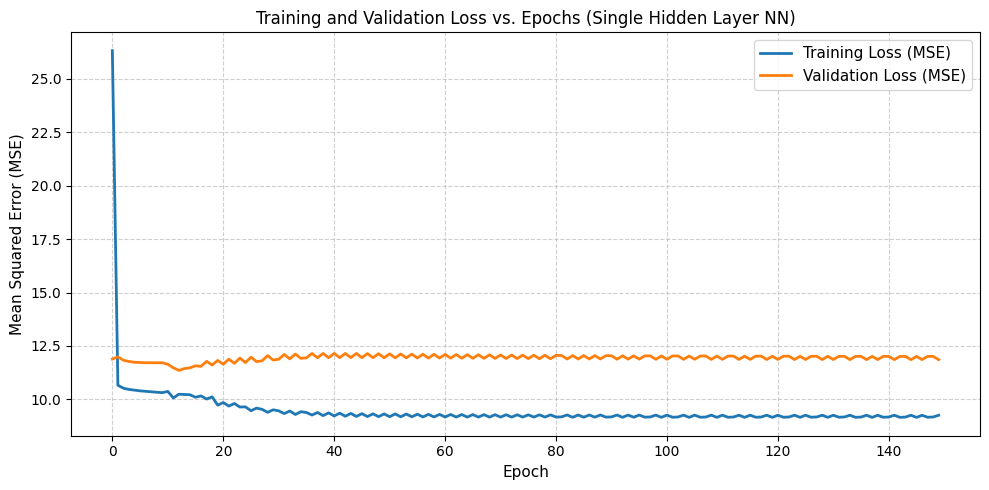

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset (housing_prices.txt)
datafile = 'housing_prices.txt'
data = np.loadtxt(datafile, delimiter=',')
X = data[:, 0:1]  # Population in 10,000s
y = data[:, 1:2]  # Price in $10,000s

# Split to 70% Train 30% Validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Standardize inputs
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

# Build NN Model
model = Sequential([
    Input(shape=(1,)),
    Dense(2, activation='relu'),
    Dense(1, activation='linear')
])

# Compile with SGD and Mean Squared Error Loss
learning_rate = 0.01
epochs = 150
optimizer = SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Train the network (batch_size=1 for Stochastic Gradient Descent)
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epochs,
    batch_size=1,
    verbose=0
)

# Evaluate on validation set
y_val_pred = model.predict(X_val_scaled, verbose=0)
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation R2 Score: {val_r2:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

# Predict price for a city with population of 165,000
# Target population in units of 10,000s
target_pop = np.array([[165000 / 10000.0]])
target_pop_scaled = scaler_X.transform(target_pop)
predicted_norm = float(model.predict(target_pop_scaled, verbose=0)[0, 0])
predicted_dollars = predicted_norm * 10000.0

print(f"\nPredicted House Price (in $10,000s): {predicted_norm:.4f}")
print(f"Predicted House Price (in USD): ${predicted_dollars:,.2f}")

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#ff7f0e', lw=2)
plt.title('Training and Validation Loss vs. Epochs (Single Hidden Layer NN)', fontsize=12)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()